<a href="https://colab.research.google.com/github/DanielBR0612/supervised-machine-learning/blob/main/atividade4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade Prática**
<font size=3>

- **Tema:** máquinas de vetores de suporte.
- **Prazo de entrega:** 28 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=header).

---

## **Enunciado:**
<font size=3>

Com base no *dataset* de [Doenças Cardíacas](https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos para resolver a tarefa de classificação:

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **1º Passo:**
<font size=3>

- Importe o *dataset* e **imprima na tela** o dataframe;
- Transformer o atributo `AgeCategory` para que o intervalo das idades seja definida como a média, *e.g.*, $[20,\, 40] \rightarrow 30$;
- Defina a variável alvo como `HeartDisease` e as demais como a variável de atributos.


In [52]:
import pandas as pd
import numpy as np
import re

In [53]:
doencas = pd.read_csv('/content/drive/MyDrive/dataset/heart_disease.csv')

In [54]:
doencas.head(30)["AgeCategory"]

,AgeCategory
0,60-64
1,35-39
2,30-34
3,55-59
4,75-79
5,30-34
6,60-64
7,60-64
8,65-69
9,45-49


In [55]:
def calcular_media_idade(idade):
  if pd.isna(idade):
    return idade

  if "older" in idade:
    numero = re.findall(r'\d+', idade)[0]
    return numero
  elif "-" in idade:
    partes = idade.split('-')
    print(f"partes: {partes}")
    inferior = int(partes[0])
    superior = int(partes[1])
    media = (inferior + superior) / 2
    return media


In [56]:
doencas["AgeCategory"] = doencas["AgeCategory"].apply(calcular_media_idade)
doencas

partes: ['60', '64']
partes: ['35', '39']
partes: ['30', '34']
partes: ['55', '59']
partes: ['75', '79']
partes: ['30', '34']
partes: ['60', '64']
partes: ['60', '64']
partes: ['65', '69']
partes: ['45', '49']
partes: ['70', '74']
partes: ['40', '44']
partes: ['65', '69']
partes: ['40', '44']
partes: ['40', '44']
partes: ['40', '44']
partes: ['40', '44']
partes: ['60', '64']
partes: ['30', '34']
partes: ['60', '64']
partes: ['50', '54']
partes: ['25', '29']
partes: ['75', '79']
partes: ['55', '59']
partes: ['60', '64']
partes: ['25', '29']
partes: ['40', '44']
partes: ['65', '69']
partes: ['18', '24']
partes: ['60', '64']
partes: ['40', '44']
partes: ['40', '44']
partes: ['35', '39']
partes: ['45', '49']
partes: ['35', '39']
partes: ['65', '69']
partes: ['50', '54']
partes: ['50', '54']
partes: ['75', '79']
partes: ['35', '39']
partes: ['65', '69']
partes: ['45', '49']
partes: ['65', '69']
partes: ['18', '24']
partes: ['60', '64']
partes: ['65', '69']
partes: ['30', '34']
partes: ['40'

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,Yes,25.06,No,No,No,30.0,30.0,Yes,Female,62.0,White,Yes,No,Poor,10.0,No,No,No
1,No,24.39,No,No,No,0.0,0.0,No,Male,37.0,White,No,Yes,Excellent,8.0,No,No,No
2,No,33.91,Yes,Yes,No,30.0,30.0,No,Male,32.0,White,No,Yes,Poor,7.0,Yes,No,No
3,No,27.79,Yes,No,No,0.0,0.0,Yes,Female,57.0,White,No,Yes,Good,7.0,No,No,No
4,No,32.89,No,No,No,30.0,15.0,Yes,Female,77.0,White,Yes,Yes,Fair,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881,No,28.04,No,No,No,2.0,1.0,Yes,Female,67.0,White,No,Yes,Good,8.0,No,No,Yes
2882,No,22.32,Yes,No,No,0.0,0.0,No,Male,32.0,White,No,Yes,Excellent,7.0,No,No,No
2883,No,23.71,No,No,No,0.0,0.0,No,Male,52.0,White,No,Yes,Very good,7.0,No,No,No
2884,No,29.76,Yes,No,No,4.0,4.0,No,Male,42.0,Hispanic,No,Yes,Good,8.0,No,No,No


In [57]:
y = doencas["HeartDisease"]
X = doencas.drop(["HeartDisease"], axis=1)


### **2º Passo:**
<font size=3>

- Utilize a função `unique` do Numpy para identificar as proporções das classes da variável `y`;
- Realize a divisão dos dados entre treinamento e teste. Caso seja necessário, faça a estratificação;
- Utilize a classe [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar `y_train` e `y_test`;
- Para transformar os dados de atributos:
    - Defina o transformador ([`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)) dos dados categóricos;
    - Defina o transformador ([`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)) dos dados numéricos.
- Defina o objeto preprocessador com a classe [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html).

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

In [59]:
np.unique(y, return_counts=True)

(array(['No', 'Yes'], dtype=object), array([2339,  547]))

In [60]:
X_train, X_dev, y_train, y_dev = train_test_split(X, y, test_size=0.4, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_dev, y_dev, test_size=0.5, stratify=y_dev)

In [61]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.fit_transform(y_val)
y_test_encoded = le.transform(y_test)

In [62]:
categorical_atributes = ["Smoking", "AlcoholDrinking", "Stroke", "DiffWalking", "Sex", "Race", "Diabetic", "PhysicalActivity", "GenHealth", "Asthma", "KidneyDisease", "SkinCancer"]
numerical_atributes = ["BMI", "PhysicalHealth", "MentalHealth", "AgeCategory", "SleepTime"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numerical_atributes),
                                               ('cat', categorical_transformer, categorical_atributes)],
                                 remainder='passthrough'
                                )

### **3º Passo:**
<font size=3>

- Defina o objeto de [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) para encadear o objeto preprocessador e o modelo de [máquina de vetores de suporte](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html);
- Para treinar o modelo, utilize a classe [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) considerando:
    - As funções kernels `linear`, `poly` e `rbf`, com seus principais hiperparâmetros;
    - 10 iterações na busca de hiperparâmetros;
    - 5 divisões para validação cruzada;
    - Métrica acurácia.
- **Imprima na tela** os melhores hiperparâmetros e valor de acurácia.    

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

In [64]:
pipe = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', SVC())])

pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['BMI', 'PhysicalHealth',
                                                   'MentalHealth',
                                                   'AgeCategory',
                                                   'SleepTime']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Smoking', 'AlcoholDrinking',
                                                   'Stroke', 'DiffWalking',
                                                   'Sex', 'Race', 'Diabetic',
                                                   'PhysicalActivity',
                                                   'GenHealth', 'Asthma',
                                                   'KidneyDisease',
                                                   'SkinCancer'])])),
                ('classifier', SVC())])

In [65]:
param_grid = {
    'classifier__kernel': ['linear', 'poly', 'rbf'],
    'classifier__C': [0.1, 1, 10, 100, 1000],
    'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'classifier__degree': [2, 3, 4, 5]
}

random_search = RandomizedSearchCV(
                  estimator=pipe,
                  param_distributions=param_grid,
                  n_iter=10,
                  cv=5,
                  scoring='accuracy',
                  random_state=42,
                  verbose=1,
                )

random_search.fit(X_train, y_train_encoded)

print("Melhores hiperparâmetros:", random_search.best_params_)
print("Melhor acurácia:", random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhores hiperparâmetros: {'classifier__kernel': 'rbf', 'classifier__gamma': 0.01, 'classifier__degree': 3, 'classifier__C': 100}
Melhor acurácia: 0.8272542519698156


### **4º Passo:**
<font size=3>

- Realize as predições com os dados de teste;
- Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) e [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) para plotar a **matriz de confusão**;
- Utilize a função [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para **imprimir na tela** os resultados da classificação;
- **Escreva** em uma **célula _markdown_** sua interpretação dos resultados.

In [69]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [67]:
y_pred = random_search.predict(X_test)

acc = accuracy_score(y_test_encoded, y_pred)

print(f"Acurácia do melhor modelo: {acc:.2f}")

Acurácia do melhor modelo: 0.84



--- Relatório de Classificação ---
              precision    recall  f1-score   support

          No       0.85      0.98      0.91       468
         Yes       0.74      0.28      0.41       110

    accuracy                           0.84       578
   macro avg       0.80      0.63      0.66       578
weighted avg       0.83      0.84      0.81       578

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       468
           1       0.74      0.28      0.41       110

    accuracy                           0.84       578
   macro avg       0.80      0.63      0.66       578
weighted avg       0.83      0.84      0.81       578



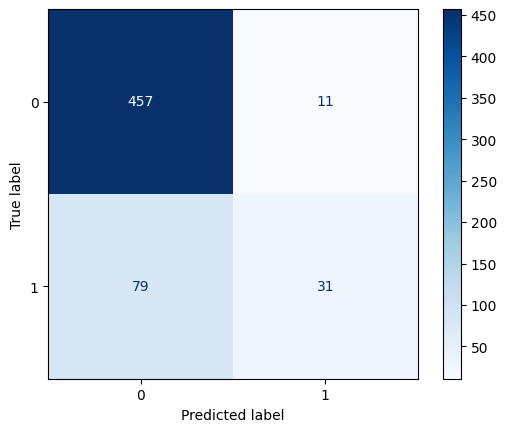

In [71]:
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=random_search.classes_)
disp.plot(cmap='Blues', values_format='d')

print(classification_report(y_test_encoded, y_pred))

O modelo apesar de ter uma acurácia alta, mostrou que é muito bom em identificar a classe 'Yes', ou seja, bom em identificar se tem doença (Recall 98%), mas a classe 'No' o modelo se mostrou ter mais dificuldade (apenas 28% de recall), provavelmente causado pelo desbalanceamento de dados das classes.